### Regression Dataset
We will create dataset using `make_regression` .

Dataset will have :
- 1000 samples (`n_samples`) ( number of rows )
- 2 features (`n_features` ) ( number of feature columns )

In [1]:
from sklearn.datasets import make_regression

In [2]:
X , y = make_regression(n_samples=1000, n_features=2, random_state=42, bias = 5, noise = 1)

In [3]:
X.shape

(1000, 2)

In [4]:
y.shape

(1000,)

### Splitting Dataset

Let's split the dataset using `train_test_split` .
- Training Data = 75%
- Testing Data = 25%

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state = 42 , test_size=0.25 )

In [7]:
X_train.shape

(750, 2)

In [8]:
y_train.shape

(750,)

### Model Architecture

Let's create a simple Sequential model with **2 fully connected layers** with **ReLU** activation in between.

In [9]:
import torch
import torch.nn as nn
import numpy as np

In [10]:
class SimpleRegressor(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self,x):
        logits = self.model(x)
        return logits

    def predict(self,x_test):
        x_test = torch.asarray(x_test,dtype=torch.float32)
        
        with torch.no_grad():
            y_pred = self.model(x_test)

        return y_pred.numpy().flatten()

    def train(self, x_train , y_train , epoch = 100):

        # converting ndarray into tensor
        x_train = torch.asarray(x_train,dtype=torch.float32)
        y_train = torch.asarray(y_train,dtype=torch.float32).view(-1,1) # 1D tensor

        # Optimizer and Loss function
        optimizer = torch.optim.Adam(self.model.parameters(),lr=0.01)
        criterion = torch.nn.MSELoss()

        # Training loop
        for _ in range(epoch):
            logits = self.model(x_train)
        
            optimizer.zero_grad()
            loss = criterion(logits,y_train)
        
            loss.backward()
            optimizer.step()


### About `SimpleRegressor` class :

we define model in __init__() as `self.model` .

Methods :
- `forward()` : Forward Pass ( returns logits )
- `train()`   : Training ( uses `Adam` optimizer to optimize weights - improves model performance )
- `predict()` : Predicting ( returns 1D numpy array ) 

In [11]:
model = SimpleRegressor()

In [12]:
model.train(X_train,y_train, epoch=1000)

### Prediction , Evaluation

We will predict the values of y using `model.predict` .

We will evaluate based on these metrics :
- `Mean Squared Error`
- `Mean Absolute Error`
- `R2 Score`

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [15]:
mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

In [16]:
print(f"Mean Square Error : {mse:.4f}")
print(f"Mean Absolute Error : {mae:.4f}")
print(f"R2 score : {r2:.4f}")

Mean Square Error : 1.1419
Mean Absolute Error : 0.8257
R2 score : 0.9992


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

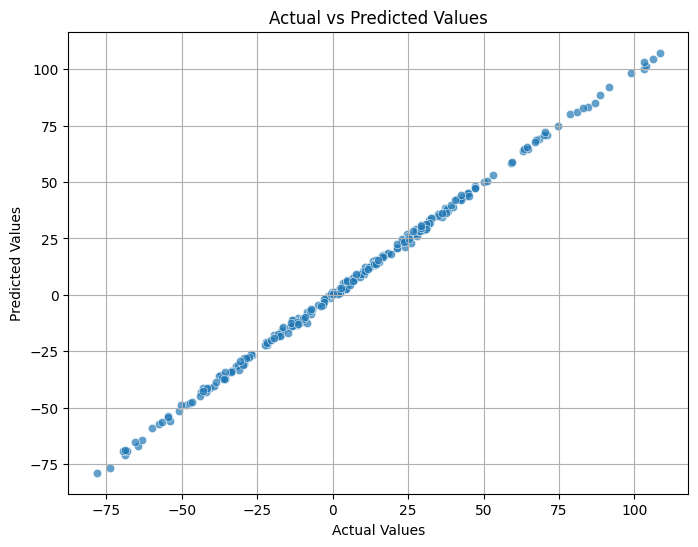

In [18]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()